## **Explorando y analisando los datos para su debida limpieza**

## Elementos


Los parámetros que InsightCluster evalúa para determinar el riesgo de un estudiante son:
1. cliente_id: Identificador único del cliente.
2. frecuencia_compra: Número de compras realizadas en un periodo definido.
3. monto_total_gastado: Gasto acumulado del cliente.
4. monto_promedio_compra: Promedio gastado por compra.
5. dias_desde_ultima_compra: Tiempo transcurrido desde la última compra.
6. antiguedad_cliente_meses: Tiempo que el cliente lleva utilizando el servicio.
7. canal_principal: Canal más utilizado (web, móvil, tienda física, etc.).
8. numero_productos_distintos: Cantidad de categorías o productos diferentes
comprados.
9. reseña_id: Identificador único de la reseña.
11. texto_reseña: Opinión escrita por el cliente.
12. fecha_reseña: Fecha en que se realizó la reseña.
13. producto_categoria: Categoría del producto reseñado.
14. longitud_reseña: Número de palabras o caracteres (deberá calcularse si se
considera necesaria).


In [1]:
#Importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [2]:
# Leer el archivo
uploaded = files.upload()  # Abre el explorador de archivos

# Cargar el primer archivo seleccionado
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

Saving data_prueba_proyecto2.csv to data_prueba_proyecto2.csv


## Vistazo al Dataset

In [3]:
print(data.shape)
print('-'*25)
data.head()

(1000, 12)
-------------------------


,cliente_id,frecuencia_compra,monto_total_gastado,monto_promedio_compra,dias_desde_ultima_compra,antiguedad_cliente_meses,canal_principal,numero_productos_distintos,fecha_reseña,producto_categoria,reseña_id,texto_reseña
0,1,15.0,12853.97,1391.9,215.0,28.0,móvil,43.0,2025-03-24,ropa,1,El diseño es atractivo y el color coincide con...
1,2,4.0,10014.12,823.06,45.0,147.0,marketplace,30.0,2024-09-15,ropa,2,La prenda es cómoda y la tela se siente agrada...
2,3,58.0,8709.53,584.38,32.0,141.0,call center,39.0,2024-09-13,alimentos,3,El sabor es aceptable y la textura resulta agr...
3,4,97.0,18510.31,237.2,130.0,NaN,tienda física,8.0,2025-06-22,educacion,4,La metodología utilizada facilita el aprendiza...
4,5,55.0,5265.05,34.47,52.0,86.0,tienda física,28.0,NaN,servicios,5,La experiencia general fue correcta pero hubo ...


In [4]:
# Identificación de las variables categóricas y numéricas
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cliente_id                  1000 non-null   int64  
 1   frecuencia_compra           993 non-null    object 
 2   monto_total_gastado         991 non-null    object 
 3   monto_promedio_compra       956 non-null    object 
 4   dias_desde_ultima_compra    971 non-null    float64
 5   antiguedad_cliente_meses    941 non-null    float64
 6   canal_principal             1000 non-null   object 
 7   numero_productos_distintos  986 non-null    float64
 8   fecha_reseña                955 non-null    object 
 9   producto_categoria          1000 non-null   object 
 10  reseña_id                   1000 non-null   int64  
 11  texto_reseña                1000 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 93.9+ KB


In [5]:
# Verificación de tipos
print(data.dtypes)

cliente_id                      int64
frecuencia_compra              object
monto_total_gastado            object
monto_promedio_compra          object
dias_desde_ultima_compra      float64
antiguedad_cliente_meses      float64
canal_principal                object
numero_productos_distintos    float64
fecha_reseña                   object
producto_categoria             object
reseña_id                       int64
texto_reseña                   object
dtype: object


## Hay varios nulls. Se tendra que hacer una limpieza, pero primero eliminamos columnas que irrelevantes

In [6]:
data = data.drop(columns=["cliente_id", "reseña_id", "fecha_reseña"])

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   frecuencia_compra           993 non-null    object 
 1   monto_total_gastado         991 non-null    object 
 2   monto_promedio_compra       956 non-null    object 
 3   dias_desde_ultima_compra    971 non-null    float64
 4   antiguedad_cliente_meses    941 non-null    float64
 5   canal_principal             1000 non-null   object 
 6   numero_productos_distintos  986 non-null    float64
 7   producto_categoria          1000 non-null   object 
 8   texto_reseña                1000 non-null   object 
dtypes: float64(3), object(6)
memory usage: 70.4+ KB


# Ahora cambiaremos los tipos de datos

In [11]:
#frecuencia_compra a float
data['frecuencia_compra'] = pd.to_numeric(data['frecuencia_compra'], errors='coerce')

In [12]:
#monto_total_gastado a float
data['monto_total_gastado'] = pd.to_numeric(data['monto_total_gastado'], errors='coerce')

In [13]:
#monto_promedio_compra a float
data['monto_promedio_compra'] = pd.to_numeric(data['monto_promedio_compra'], errors='coerce')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   frecuencia_compra           981 non-null    float64
 1   monto_total_gastado         973 non-null    float64
 2   monto_promedio_compra       952 non-null    float64
 3   dias_desde_ultima_compra    971 non-null    float64
 4   antiguedad_cliente_meses    941 non-null    float64
 5   canal_principal             1000 non-null   object 
 6   numero_productos_distintos  986 non-null    float64
 7   producto_categoria          1000 non-null   object 
 8   texto_reseña                1000 non-null   object 
dtypes: float64(6), object(3)
memory usage: 70.4+ KB


# Rellenar nulls

# Se usara la mediana para un mejor manejo de outlier

In [15]:
#Frecuencia compra rellenar con la mediana
data["frecuencia_compra"] = data["frecuencia_compra"].fillna(data["frecuencia_compra"].median())

In [16]:
#monto_total_gastado rellenar con la mediana
data["monto_total_gastado"] = data["monto_total_gastado"].fillna(data["monto_total_gastado"].median())

In [17]:
#monto_promedio_compra rellenar con la mediana
data["monto_promedio_compra"] = data["monto_promedio_compra"].fillna(data["monto_promedio_compra"].median())

In [18]:
#antiguedad_clientes_meses
data["antiguedad_cliente_meses"] = data["antiguedad_cliente_meses"].fillna(data["antiguedad_cliente_meses"].median())

In [19]:
#numero_productos_distintos
data["numero_productos_distintos"] = data["numero_productos_distintos"].fillna(data["numero_productos_distintos"].median())

# Para dias desde la ultima compra se maneja difente

Mide "inactividad" o "frescura" del cliente

In [20]:
# PRIMERO verifica la distribución
print("Estadísticas de dias_desde_ultima_compra:")
print(data["dias_desde_ultima_compra"].describe())
print(f"\nMediana: {data['dias_desde_ultima_compra'].median()}")
print(f"Media: {data['dias_desde_ultima_compra'].mean()}")

Estadísticas de dias_desde_ultima_compra:
count    971.000000
mean     184.023687
std      105.491977
min        0.000000
25%       96.000000
50%      187.000000
75%      276.000000
max      365.000000
Name: dias_desde_ultima_compra, dtype: float64

Mediana: 187.0
Media: 184.0236869207003


In [21]:
# Opción segura para clustering:
data["dias_desde_ultima_compra"] = data["dias_desde_ultima_compra"].fillna(
    data["dias_desde_ultima_compra"].median()
)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   frecuencia_compra           1000 non-null   float64
 1   monto_total_gastado         1000 non-null   float64
 2   monto_promedio_compra       1000 non-null   float64
 3   dias_desde_ultima_compra    1000 non-null   float64
 4   antiguedad_cliente_meses    1000 non-null   float64
 5   canal_principal             1000 non-null   object 
 6   numero_productos_distintos  1000 non-null   float64
 7   producto_categoria          1000 non-null   object 
 8   texto_reseña                1000 non-null   object 
dtypes: float64(6), object(3)
memory usage: 70.4+ KB


🔍 INICIANDO ANÁLISIS COMPLETO DE OUTLIERS

ANÁLISIS DE: frecuencia_compra
📊 ESTADÍSTICAS DESCRIPTIVAS:
count    1000.000000
mean       51.373000
std        29.229441
min         0.000000
25%        26.000000
50%        53.000000
75%        77.000000
max       100.000000

🔍 MÉTODO IQR (Q1-1.5*IQR, Q3+1.5*IQR):
   • Q1: 26.00, Q3: 77.00, IQR: 51.00
   • Límites: [-50.50, 153.50]
   • Outliers detectados: 0 (0.0%)

📈 MÉTODO Z-SCORE (>3 desviaciones):
   • Outliers detectados: 0 (0.0%)

¿Ver gráfico interactivo para frecuencia_compra? (s/n): s



ANÁLISIS DE: monto_total_gastado
📊 ESTADÍSTICAS DESCRIPTIVAS:
count     1000.000000
mean     10208.622040
std       5773.966425
min          1.250000
25%       5085.352500
50%      10388.750000
75%      15117.827500
max      19987.110000

🔍 MÉTODO IQR (Q1-1.5*IQR, Q3+1.5*IQR):
   • Q1: 5085.35, Q3: 15117.83, IQR: 10032.47
   • Límites: [-9963.36, 30166.54]
   • Outliers detectados: 0 (0.0%)

📈 MÉTODO Z-SCORE (>3 desviaciones):
   • Outliers detectados: 0 (0.0%)

¿Ver gráfico interactivo para monto_total_gastado? (s/n): s



ANÁLISIS DE: monto_promedio_compra
📊 ESTADÍSTICAS DESCRIPTIVAS:
count    1000.000000
mean      762.896380
std       420.240519
min         2.970000
25%       416.017500
50%       781.230000
75%      1105.250000
max      1497.910000

🔍 MÉTODO IQR (Q1-1.5*IQR, Q3+1.5*IQR):
   • Q1: 416.02, Q3: 1105.25, IQR: 689.23
   • Límites: [-617.83, 2139.10]
   • Outliers detectados: 0 (0.0%)

📈 MÉTODO Z-SCORE (>3 desviaciones):
   • Outliers detectados: 0 (0.0%)

¿Ver gráfico interactivo para monto_promedio_compra? (s/n): s



ANÁLISIS DE: dias_desde_ultima_compra
📊 ESTADÍSTICAS DESCRIPTIVAS:
count    1000.000000
mean      184.110000
std       103.950737
min         0.000000
25%        99.000000
50%       187.000000
75%       272.250000
max       365.000000

🔍 MÉTODO IQR (Q1-1.5*IQR, Q3+1.5*IQR):
   • Q1: 99.00, Q3: 272.25, IQR: 173.25
   • Límites: [-160.88, 532.12]
   • Outliers detectados: 0 (0.0%)

📈 MÉTODO Z-SCORE (>3 desviaciones):
   • Outliers detectados: 0 (0.0%)

¿Ver gráfico interactivo para dias_desde_ultima_compra? (s/n): s



ANÁLISIS DE: antiguedad_cliente_meses
📊 ESTADÍSTICAS DESCRIPTIVAS:
count    1000.000000
mean      119.655000
std        65.890284
min         0.000000
25%        64.750000
50%       118.000000
75%       177.000000
max       240.000000

🔍 MÉTODO IQR (Q1-1.5*IQR, Q3+1.5*IQR):
   • Q1: 64.75, Q3: 177.00, IQR: 112.25
   • Límites: [-103.62, 345.38]
   • Outliers detectados: 0 (0.0%)

📈 MÉTODO Z-SCORE (>3 desviaciones):
   • Outliers detectados: 0 (0.0%)

¿Ver gráfico interactivo para antiguedad_cliente_meses? (s/n): s



ANÁLISIS DE: numero_productos_distintos
📊 ESTADÍSTICAS DESCRIPTIVAS:
count    1000.000000
mean       26.488000
std        14.100538
min         1.000000
25%        15.000000
50%        27.500000
75%        38.000000
max        50.000000

🔍 MÉTODO IQR (Q1-1.5*IQR, Q3+1.5*IQR):
   • Q1: 15.00, Q3: 38.00, IQR: 23.00
   • Límites: [-19.50, 72.50]
   • Outliers detectados: 0 (0.0%)

📈 MÉTODO Z-SCORE (>3 desviaciones):
   • Outliers detectados: 0 (0.0%)

¿Ver gráfico interactivo para numero_productos_distintos? (s/n): s



📋 RESUMEN GENERAL DE OUTLIERS
                   Columna  Total Datos  Outliers IQR % Outliers IQR  Outliers Z-score % Outliers Z Límite Inferior Límite Superior
         frecuencia_compra         1000             0           0.0%                 0         0.0%          -50.50          153.50
       monto_total_gastado         1000             0           0.0%                 0         0.0%        -9963.36        30166.54
     monto_promedio_compra         1000             0           0.0%                 0         0.0%         -617.83         2139.10
  dias_desde_ultima_compra         1000             0           0.0%                 0         0.0%         -160.88          532.12
  antiguedad_cliente_meses         1000             0           0.0%                 0         0.0%         -103.62          345.38
numero_productos_distintos         1000             0           0.0%                 0         0.0%          -19.50           72.50

🛠️  TRATAMIENTO DE OUTLIERS

Elige método de

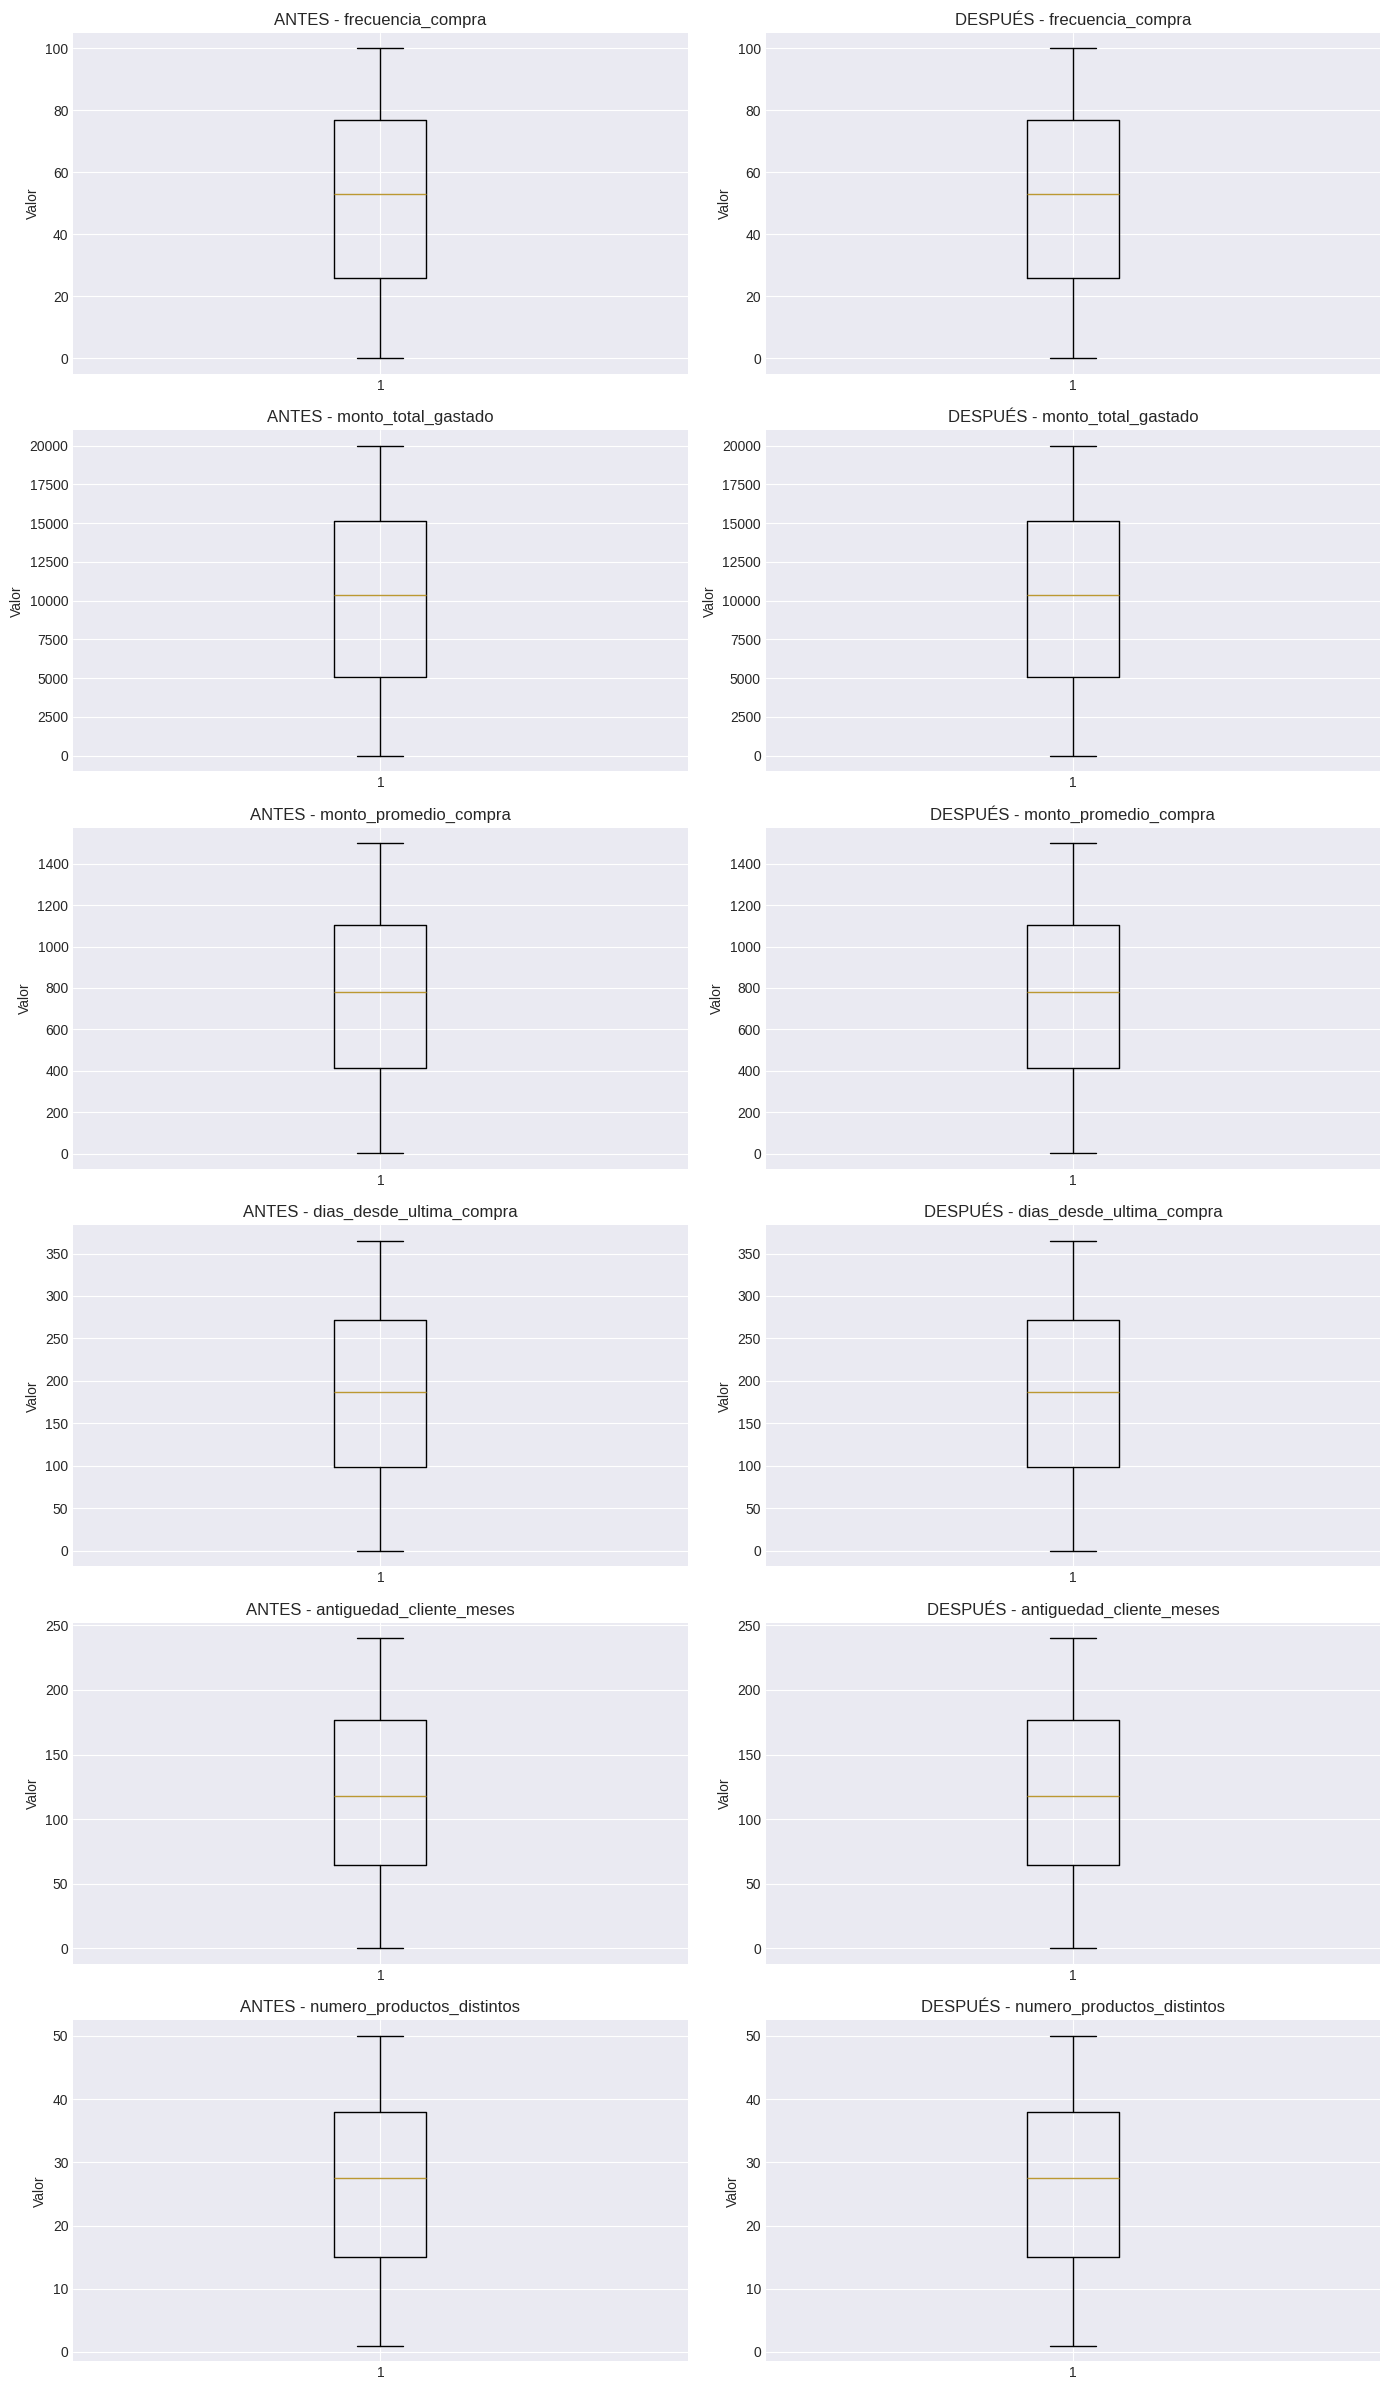


💾 EXPORTAR RESULTADOS
¿Exportar datos tratados a CSV? (s/n): s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivo descargado: 'datos_sin_outliers.csv'

🤖 PREPARACIÓN PARA CLUSTERING

Selecciona scaler para clustering:
1. StandardScaler (recomendado si outliers están controlados)
2. RobustScaler (usa mediana/IQR, más robusto)
Opción (1-2): 1

✅ Datos escalados con StandardScaler
   • Forma: (1000, 6)
   • Media de cada columna escalada: [ 0.  0. -0. -0. -0.  0.]
   • Std de cada columna escalada: [1. 1. 1. 1. 1. 1.]

Primeras 5 filas escaladas:
   frecuencia_compra_scaled  monto_total_gastado_scaled  monto_promedio_compra_scaled  dias_desde_ultima_compra_scaled  antiguedad_cliente_meses_scaled  numero_productos_distintos_scaled
0                 -1.245019                    0.458380                      1.497519                         0.297309                        -1.391721                           1.171605
1                 -1.621540                   -0.033703                      0.143236                        -1.338900                         0.415216                           0.

In [23]:
# ======================
# 1. INSTALAR LIBRERÍAS (si es necesario)
# ======================
!pip install seaborn plotly -q

# ======================
# 2. IMPORTAR
# ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# ======================
# 3. FUNCIONES PARA OUTLIERS
# ======================

def analizar_outliers_completo(df, columna):
    """Análisis completo de una columna"""
    print(f"\n{'='*60}")
    print(f"ANÁLISIS DE: {columna}")
    print(f"{'='*60}")

    # Estadísticas básicas
    print("📊 ESTADÍSTICAS DESCRIPTIVAS:")
    print(df[columna].describe().to_string())

    # Método IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR

    outliers_iqr = df[(df[columna] < lower_iqr) | (df[columna] > upper_iqr)]
    perc_iqr = (len(outliers_iqr) / len(df)) * 100

    print(f"\n🔍 MÉTODO IQR (Q1-1.5*IQR, Q3+1.5*IQR):")
    print(f"   • Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"   • Límites: [{lower_iqr:.2f}, {upper_iqr:.2f}]")
    print(f"   • Outliers detectados: {len(outliers_iqr)} ({perc_iqr:.1f}%)")

    # Método Z-score (threshold=3)
    z_scores = np.abs(stats.zscore(df[columna].dropna()))
    outliers_z = df[columna].iloc[np.where(z_scores > 3)[0]]
    perc_z = (len(outliers_z) / len(df)) * 100

    print(f"\n📈 MÉTODO Z-SCORE (>3 desviaciones):")
    print(f"   • Outliers detectados: {len(outliers_z)} ({perc_z:.1f}%)")

    return {
        'columna': columna,
        'outliers_iqr': outliers_iqr,
        'outliers_z': outliers_z,
        'limites_iqr': (lower_iqr, upper_iqr),
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR
    }

def graficar_outliers_interactivo(df, columna, limites):
    """Gráfico interactivo con Plotly"""
    lower, upper = limites

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(f'Distribución de {columna}',
                       f'Box Plot - {columna}',
                       f'Histograma con límites - {columna}',
                       f'Valores extremos - {columna}'),
        specs=[[{"type": "scatter"}, {"type": "box"}],
               [{"type": "histogram"}, {"type": "scatter"}]]
    )

    # Scatter plot
    fig.add_trace(
        go.Scatter(
            x=df.index, y=df[columna],
            mode='markers',
            name='Datos',
            marker=dict(color='blue', size=6, opacity=0.6)
        ),
        row=1, col=1
    )

    # Líneas de límites
    fig.add_hline(y=lower, line_dash="dash", line_color="red",
                  annotation_text=f"Límite inferior: {lower:.2f}",
                  row=1, col=1)
    fig.add_hline(y=upper, line_dash="dash", line_color="red",
                  annotation_text=f"Límite superior: {upper:.2f}",
                  row=1, col=1)

    # Box plot
    fig.add_trace(
        go.Box(y=df[columna], name=columna, boxmean=True),
        row=1, col=2
    )

    # Histograma
    fig.add_trace(
        go.Histogram(x=df[columna], name='Distribución',
                    nbinsx=50, marker_color='green'),
        row=2, col=1
    )

    # Marcar outliers
    outliers = df[(df[columna] < lower) | (df[columna] > upper)]
    fig.add_trace(
        go.Scatter(
            x=outliers.index, y=outliers[columna],
            mode='markers',
            name='Outliers IQR',
            marker=dict(color='red', size=10, symbol='x')
        ),
        row=2, col=2
    )

    fig.update_layout(height=800, showlegend=True,
                     title_text=f"Análisis de Outliers: {columna}")
    fig.show()

# ======================
# 4. APLICAR A TUS DATOS
# ======================

# Suponiendo que ya tienes tu DataFrame 'data' cargado
# Si no, carga tus datos:
# from google.colab import files
# uploaded = files.upload()
# data = pd.read_csv('tu_archivo.csv')

# Seleccionar columnas numéricas (ajusta según tus datos)
columnas_numericas = [
    'frecuencia_compra',
    'monto_total_gastado',
    'monto_promedio_compra',
    'dias_desde_ultima_compra',
    'antiguedad_cliente_meses',
    'numero_productos_distintos'
]

# Crear copia para análisis
df_analysis = data[columnas_numericas].copy()

print("🔍 INICIANDO ANÁLISIS COMPLETO DE OUTLIERS")
print("="*60)

# Diccionario para guardar resultados
resultados_outliers = {}

# Análisis columna por columna
for col in columnas_numericas:
    if col in df_analysis.columns:
        resultados = analizar_outliers_completo(df_analysis, col)
        resultados_outliers[col] = resultados

        # Preguntar si ver gráfico interactivo
        ver_grafico = input(f"\n¿Ver gráfico interactivo para {col}? (s/n): ")
        if ver_grafico.lower() == 's':
            graficar_outliers_interactivo(df_analysis, col, resultados['limites_iqr'])

# ======================
# 5. RESUMEN GENERAL
# ======================
print("\n" + "="*60)
print("📋 RESUMEN GENERAL DE OUTLIERS")
print("="*60)

resumen_df = []
for col, res in resultados_outliers.items():
    resumen_df.append({
        'Columna': col,
        'Total Datos': len(df_analysis),
        'Outliers IQR': len(res['outliers_iqr']),
        '% Outliers IQR': f"{(len(res['outliers_iqr'])/len(df_analysis))*100:.1f}%",
        'Outliers Z-score': len(res['outliers_z']),
        '% Outliers Z': f"{(len(res['outliers_z'])/len(df_analysis.dropna(subset=[col])))*100:.1f}%" if not df_analysis[col].isna().all() else 'N/A',
        'Límite Inferior': f"{res['limites_iqr'][0]:.2f}",
        'Límite Superior': f"{res['limites_iqr'][1]:.2f}"
    })

resumen_df = pd.DataFrame(resumen_df)
print(resumen_df.to_string(index=False))

# ======================
# 6. TRATAMIENTO DE OUTLIERS (INTERACTIVO)
# ======================
print("\n" + "="*60)
print("🛠️  TRATAMIENTO DE OUTLIERS")
print("="*60)

print("\nElige método de tratamiento:")
print("1. Winsorization (recomendado para clustering)")
print("2. Cap con límites IQR")
print("3. Eliminar outliers")
print("4. Transformación logarítmica")
print("5. Mantener sin cambios")

opcion = input("\nSelecciona opción (1-5): ")

df_tratado = df_analysis.copy()

if opcion == '1':
    # Winsorization
    print("\nAplicando Winsorization (percentiles 5-95)...")
    for col in columnas_numericas:
        lower = df_tratado[col].quantile(0.05)
        upper = df_tratado[col].quantile(0.95)
        df_tratado[col] = df_tratado[col].clip(lower=lower, upper=upper)
    print("✅ Winsorization aplicada")

elif opcion == '2':
    # Cap con IQR
    print("\nAplicando capping con límites IQR...")
    for col in columnas_numericas:
        res = resultados_outliers[col]
        lower, upper = res['limites_iqr']
        # Para valores que no pueden ser negativos
        if df_tratado[col].min() >= 0:
            lower = max(lower, 0)
        df_tratado[col] = df_tratado[col].clip(lower=lower, upper=upper)
    print("✅ Capping aplicado")

elif opcion == '3':
    # Eliminar outliers
    print("\nEliminando outliers...")
    mask = pd.Series([True] * len(df_tratado))
    for col in columnas_numericas:
        res = resultados_outliers[col]
        lower, upper = res['limites_iqr']
        col_mask = (df_tratado[col] >= lower) & (df_tratado[col] <= upper)
        mask = mask & col_mask

    df_tratado = df_tratado[mask]
    print(f"✅ Outliers eliminados. Datos restantes: {len(df_tratado)}/{len(df_analysis)}")

elif opcion == '4':
    # Transformación logarítmica
    print("\nAplicando transformación logarítmica (log1p)...")
    for col in columnas_numericas:
        if (df_tratado[col] > 0).all():
            df_tratado[f'{col}_log'] = np.log1p(df_tratado[col])
            print(f"  ✅ {col} transformada")
        else:
            print(f"  ⚠️  {col} tiene valores ≤0, no se transforma")

# ======================
# 7. VISUALIZAR COMPARACIÓN
# ======================
print("\n" + "="*60)
print("📊 COMPARACIÓN ANTES/DESPUÉS")
print("="*60)

# Gráfico de comparación
fig, axes = plt.subplots(len(columnas_numericas), 2, figsize=(14, 4*len(columnas_numericas)))

for idx, col in enumerate(columnas_numericas):
    if col in df_tratado.columns:  # Verificar que exista en tratado
        # ANTES
        axes[idx, 0].boxplot(df_analysis[col].dropna())
        axes[idx, 0].set_title(f'ANTES - {col}')
        axes[idx, 0].set_ylabel('Valor')

        # DESPUÉS
        axes[idx, 1].boxplot(df_tratado[col].dropna())
        axes[idx, 1].set_title(f'DESPUÉS - {col}')
        axes[idx, 1].set_ylabel('Valor')

plt.tight_layout()
plt.show()

# ======================
# 8. EXPORTAR RESULTADOS
# ======================
print("\n" + "="*60)
print("💾 EXPORTAR RESULTADOS")
print("="*60)

exportar = input("¿Exportar datos tratados a CSV? (s/n): ")
if exportar.lower() == 's':
    # Guardar en Colab
    df_tratado.to_csv('datos_sin_outliers.csv', index=False)

    # Descargar a tu computadora
    from google.colab import files
    files.download('datos_sin_outliers.csv')
    print("✅ Archivo descargado: 'datos_sin_outliers.csv'")

# ======================
# 9. PREPARAR PARA CLUSTERING
# ======================
print("\n" + "="*60)
print("🤖 PREPARACIÓN PARA CLUSTERING")
print("="*60)

from sklearn.preprocessing import StandardScaler, RobustScaler

print("\nSelecciona scaler para clustering:")
print("1. StandardScaler (recomendado si outliers están controlados)")
print("2. RobustScaler (usa mediana/IQR, más robusto)")

scaler_opcion = input("Opción (1-2): ")

if scaler_opcion == '1':
    scaler = StandardScaler()
    nombre_scaler = "StandardScaler"
else:
    scaler = RobustScaler()
    nombre_scaler = "RobustScaler"

# Aplicar scaling
X_scaled = scaler.fit_transform(df_tratado[columnas_numericas])
df_scaled = pd.DataFrame(X_scaled, columns=[f'{col}_scaled' for col in columnas_numericas])

print(f"\n✅ Datos escalados con {nombre_scaler}")
print(f"   • Forma: {df_scaled.shape}")
print(f"   • Media de cada columna escalada: {df_scaled.mean().values.round(2)}")
print(f"   • Std de cada columna escalada: {df_scaled.std().values.round(2)}")

# Mostrar primeras filas
print("\nPrimeras 5 filas escaladas:")
print(df_scaled.head().to_string())

print("\n🎯 ¡Análisis de outliers completado! Ya puedes proceder con clustering.")